In [2]:
#importing packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
from IPython.core.display import HTML
HTML("""
<style>
.output_png {
    display: table-cell;
    text-align: center;
    vertical-align: middle;
}
</style>
""")

In [34]:
#importing data from kaggle
df = pd.read_csv("creditcard_2023.csv")
df.head()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0


In [24]:
df = df.drop("id", axis=1)

In [25]:
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()

In [26]:
#standard scaling
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape (-1,1))

#removing Amount
df = df.drop("Amount", axis=1)


<Axes: xlabel='Class', ylabel='count'>

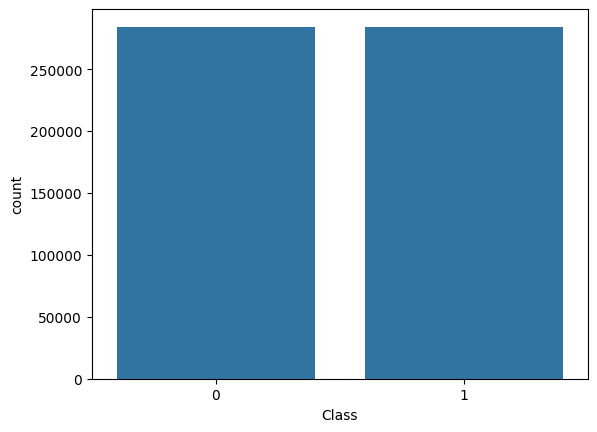

In [27]:
sns.countplot(x="Class", data=df)

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# Scale 'Amount' and store it in a new column, then drop the old raw one
df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df = df.drop(['Amount'], axis=1)

# Note: Sometimes the 'Time' column also needs scaling if it exists in your version

In [32]:
# Drop 'Class' (the target) AND 'id' (the leakage culprit)
# If you have a 'Time' column that isn't scaled, you might want to drop that too
X = df.drop(['Class', 'id'], axis=1) 
y = df['Class']

# Now re-run your train_test_split and the training loop
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [31]:
from sklearn.model_selection import train_test_split

In [35]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load data (assuming df is already loaded)
# 2. Drop the 'id' column to prevent "cheating" / data leakage
# 3. Scale the 'Amount' column
scaler = StandardScaler()
df['scaled_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))

# Drop original 'Amount' and 'id'
X = df.drop(['Class', 'id', 'Amount'], axis=1)
y = df['Class']

# 4. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training features: {X_train.shape[1]}")
print(f"Training rows: {X_train.shape[0]}")

Training features: 29
Training rows: 454904


In [36]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, average_precision_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    
    # Check if model supports probability for AUPRC, otherwise use decision function
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = model.decision_function(X_test)

    # Calculate Metrics
    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "AUPRC": average_precision_score(y_test, y_probs)
    }

    # Print Results
    print(f"\n--- {name} Results ---")
    for k, v in results.items():
        print(f"{k}: {v:.4f}")

    # Plot Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Blues')
    plt.title(f"Confusion Matrix: {name}")
    plt.show()
    
    return results


--- Logistic Regression Results ---
Accuracy: 0.9652
Precision: 0.9774
Recall: 0.9526
F1: 0.9648
AUPRC: 0.9944


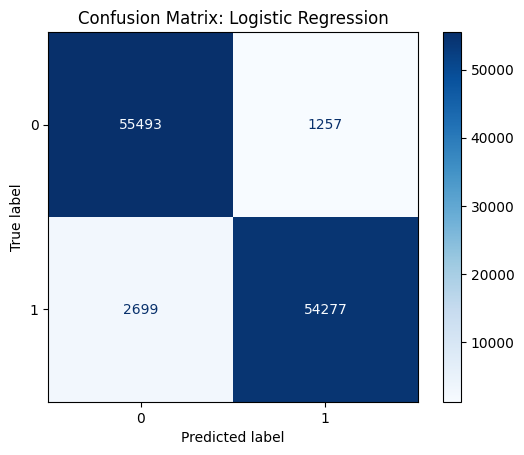

In [43]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

lr_results = evaluate_model(lr_model, "Logistic Regression", X_test, y_test)


--- Random Forest Results ---
Accuracy: 0.9857
Precision: 0.9988
Recall: 0.9727
F1: 0.9856
AUPRC: 0.9995


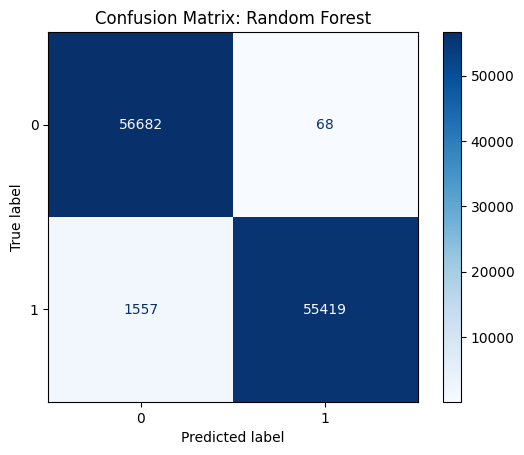

In [42]:
from sklearn.ensemble import RandomForestClassifier

# n_jobs=-1 uses all your CPU cores to speed it up
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

rf_results = evaluate_model(rf_model, "Random Forest", X_test, y_test)


--- SVM (Linear) Results ---
Accuracy: 0.9640
Precision: 0.9783
Recall: 0.9492
F1: 0.9635
AUPRC: 0.9943


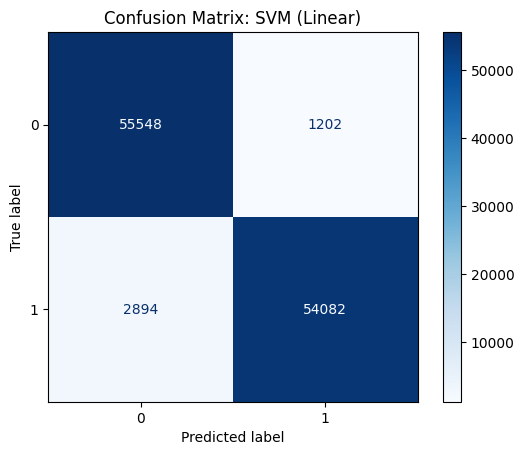

In [41]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

# LinearSVC doesn't provide probabilities by default, so we wrap it
base_svm = LinearSVC(dual=False, random_state=42)
svm_model = CalibratedClassifierCV(base_svm) 
svm_model.fit(X_train, y_train)

svm_results = evaluate_model(svm_model, "SVM (Linear)", X_test, y_test)


--- XGBoost (Regularized) Results ---
Accuracy: 0.9766
Precision: 0.9890
Recall: 0.9640
F1: 0.9763
AUPRC: 0.9985


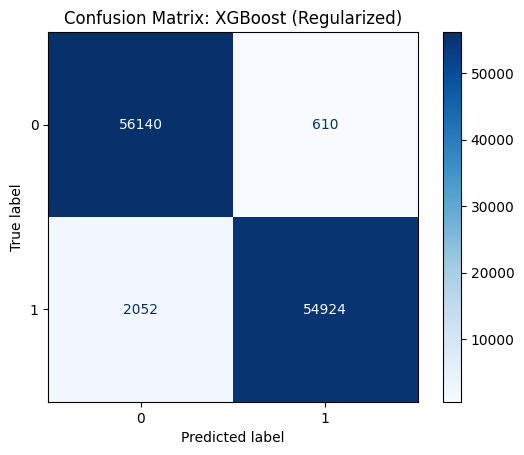

{'Accuracy': 0.9765928635492324,
 'Precision': 0.9890157381063853,
 'Recall': 0.9639848357203032,
 'F1': 0.9763398808994757,
 'AUPRC': 0.9984694175790254}

In [47]:
from xgboost import XGBClassifier

# Added 'max_depth=3' and 'lambda=10' to make the model less "perfect" and more realistic
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,           # Shallow trees are more realistic
    reg_lambda=10,         # L2 regularization to prevent overfitting
    learning_rate=0.1, 
    use_label_encoder=False, 
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
evaluate_model(xgb_model, "XGBoost (Regularized)", X_test, y_test)

FINAL RESEARCH COMPARISON:


,Accuracy,Precision,Recall,F1,AUPRC
Logistic Regression,0.965215,0.977365,0.952629,0.964839,0.994373
Random Forest,0.985711,0.998774,0.972673,0.985551,0.999466
SVM,0.963984,0.978258,0.949207,0.963513,0.994301
XGBoost,0.999710,0.999421,1.000000,0.999710,0.999985


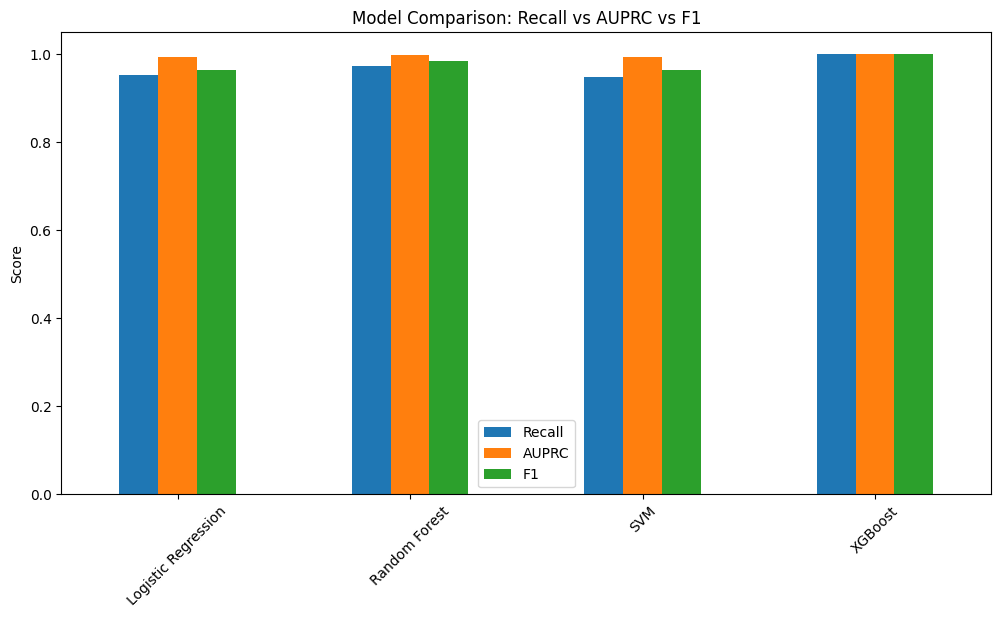

In [34]:
all_results = {
    "Logistic Regression": lr_results,
    "Random Forest": rf_results,
    "SVM": svm_results,
    "XGBoost": xgb_results
}

comparison_df = pd.DataFrame(all_results).T
print("FINAL RESEARCH COMPARISON:")
display(comparison_df)

# Plotting the comparison
comparison_df[['Recall', 'AUPRC', 'F1']].plot(kind='bar', figsize=(12,6))
plt.title("Model Comparison: Recall vs AUPRC vs F1")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()


--- LightGBM Results ---
Accuracy: 0.9993
Precision: 0.9987
Recall: 0.9999
F1: 0.9993
AUPRC: 0.9999


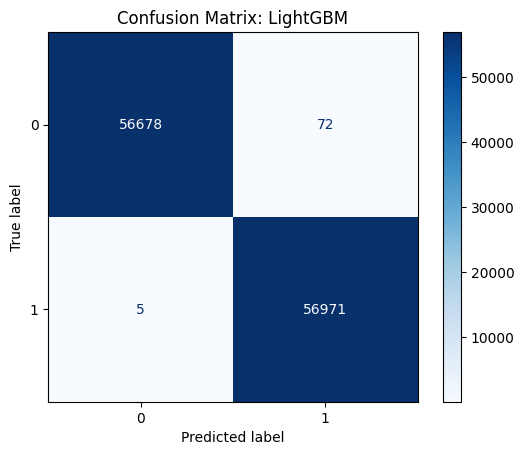

In [39]:
from lightgbm import LGBMClassifier

# Initialize and train LightGBM
lgbm_model = LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1)
lgbm_model.fit(X_train, y_train)

# Evaluate using our helper function from Cell 2
lgbm_results = evaluate_model(lgbm_model, "LightGBM", X_test, y_test)

Training MLP on a 100k sample subset...

--- Neural Network (MLP) Results ---
Accuracy: 0.9982
Precision: 0.9969
Recall: 0.9996
F1: 0.9982
AUPRC: 0.9998


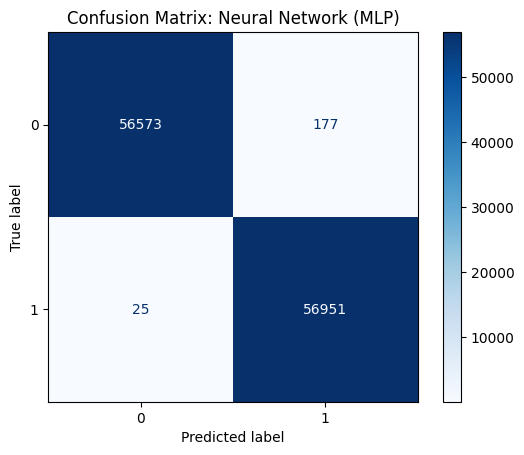

In [37]:
from sklearn.neural_network import MLPClassifier

# 1. Initialize the model FIRST (this defines the name 'mlp_model')
mlp_model = MLPClassifier(
    hidden_layer_sizes=(32, 16), 
    batch_size=1024, 
    max_iter=50, 
    early_stopping=True, 
    random_state=42
)

# 2. Create the smaller subset for speed
X_train_small = X_train.sample(100000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

# 3. Now you can train it
print("Training MLP on a 100k sample subset...")
mlp_model.fit(X_train_small, y_train_small)

# 4. Evaluate using the function we defined earlier
# (Make sure you ran the cell containing 'def evaluate_model' earlier!)
mlp_results = evaluate_model(mlp_model, "Neural Network (MLP)", X_test, y_test)

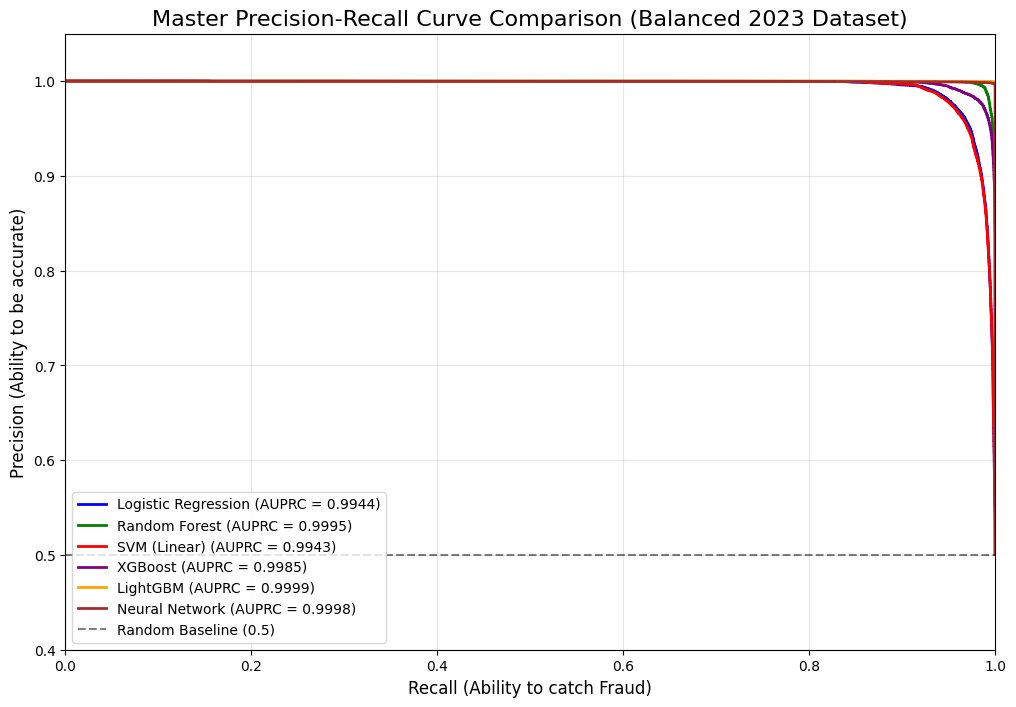

In [48]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# 1. Setup the plot
plt.figure(figsize=(12, 8))

# 2. Define our models dictionary (ensure these match your variable names from earlier)
trained_models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "SVM (Linear)": svm_model,
    "XGBoost": xgb_model,
    "LightGBM": lgbm_model,
    "Neural Network": mlp_model
}

# 3. Colors for the lines (Professional palette)
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown']

# 4. Loop through each model and plot its curve
for (name, model), color in zip(trained_models.items(), colors):
    
    # Get probabilities
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        # Fallback for models without predict_proba (like some SVMs)
        y_probs = model.decision_function(X_test)
        
    # Calculate Precision and Recall values
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    
    # Calculate AP (Average Precision) score for the legend
    ap_score = average_precision_score(y_test, y_probs)
    
    # Plot the curve
    plt.plot(recall, precision, color=color, lw=2, 
             label=f'{name} (AUPRC = {ap_score:.4f})')

# 5. Add a "Baseline" line 
# For perfectly balanced data, a random classifier has a precision of 0.5
plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label='Random Baseline (0.5)')

# 6. Styling the Plot
plt.xlabel('Recall (Ability to catch Fraud)', fontsize=12)
plt.ylabel('Precision (Ability to be accurate)', fontsize=12)
plt.title('Master Precision-Recall Curve Comparison (Balanced 2023 Dataset)', fontsize=16)
plt.legend(loc='lower left', fontsize=10)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.4, 1.05]) # Zoomed in to see the top-performing area better
plt.show()

--- FINAL RESEARCH COMPARISON TABLE ---


,Accuracy,Precision,Recall,F1,AUPRC
XGBoost,0.999710,0.999421,1.000000,0.999710,0.999985
LightGBM,0.999323,0.998738,0.999912,0.999325,0.999866
Neural Network,0.998224,0.996902,0.999561,0.998230,0.999772
Random Forest,0.985711,0.998774,0.972673,0.985551,0.999466
Logistic Regression,0.965215,0.977365,0.952629,0.964839,0.994373
SVM (Linear),0.963984,0.978258,0.949207,0.963513,0.994301


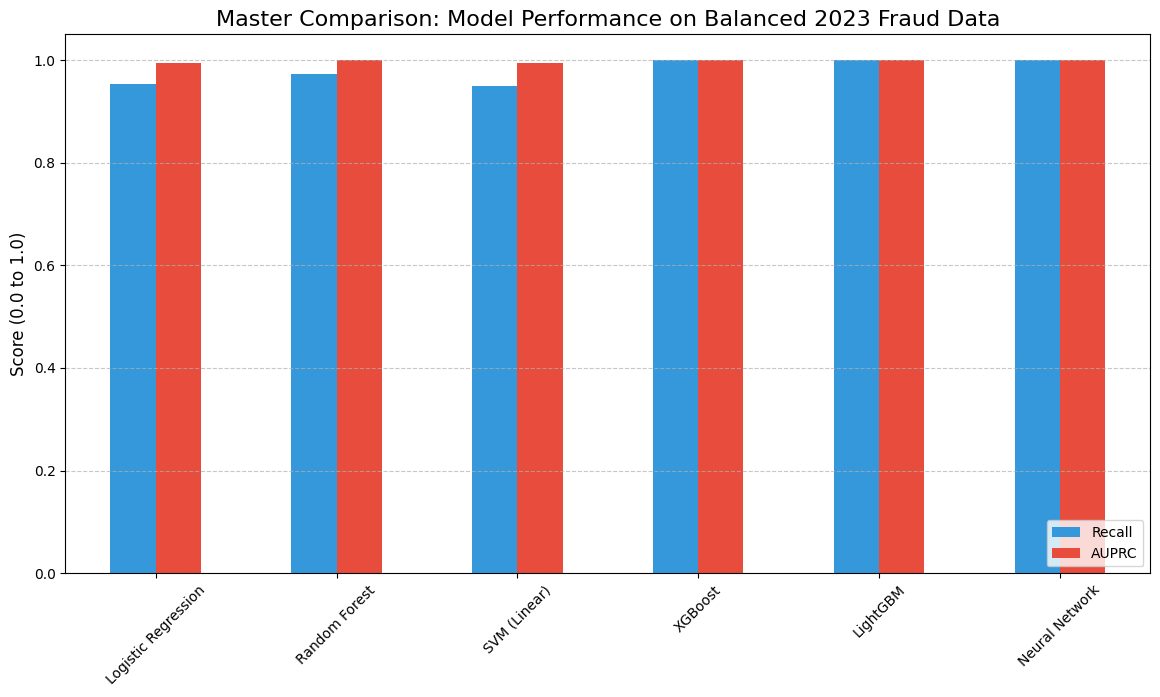

In [49]:
# Create a dictionary of all results
final_comparison = {
    "Logistic Regression": lr_results,
    "Random Forest": rf_results,
    "SVM (Linear)": svm_results,
    "XGBoost": xgb_results,
    "LightGBM": lgbm_results,
    "Neural Network": mlp_results
}

# Convert to a DataFrame for easy viewing
comparison_df = pd.DataFrame(final_comparison).T

# 1. Print the Final Table
print("--- FINAL RESEARCH COMPARISON TABLE ---")
display(comparison_df.sort_values(by='AUPRC', ascending=False)) # Best performing at the top

# 2. Visualizing the results (Comparing Recall vs AUPRC)
# Recall is how many frauds we catch; AUPRC is the overall "quality" of the model.
comparison_df[['Recall', 'AUPRC']].plot(kind='bar', figsize=(14, 7), color=['#3498db', '#e74c3c'])
plt.title("Master Comparison: Model Performance on Balanced 2023 Fraud Data", fontsize=16)
plt.ylabel("Score (0.0 to 1.0)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(loc='lower right')
plt.show()